# Bank Computer Vision — End-to-End ATM Condition Classification

## Business Case

A bank operates a large ATM network. Periodically, cameras or inspection systems can capture ATM images.

The objective is to automatically classify the visual condition:

- **Normal**
- **Damaged**
- **Obstructed**

This is a synthetic educational project. The images are generated only to demonstrate a complete Computer Vision workflow.

## End-to-End Flow

```text
ATM Image
   ↓
Image Preprocessing
   ↓
Feature Extraction / CNN
   ↓
Classification
   ↓
Normal / Damaged / Obstructed
   ↓
Operational Alert
   ↓
Maintenance Action
```

## 1. What is Computer Vision?

Computer Vision enables computers to extract information from images and video.

Banking examples include:

- ATM condition monitoring
- document image classification
- cheque processing
- OCR
- identity-document analysis
- face verification
- branch queue monitoring
- card/document quality inspection
- image-based fraud signals

This notebook focuses on **image classification**.

## 2. Why This Case?

For an ATM network, manual inspection can be expensive.

A Computer Vision system can help prioritize locations:

```text
Thousands of ATM Images
        ↓
Computer Vision
        ↓
Condition Classification
        ↓
Potentially Damaged ATMs
        ↓
Maintenance Queue
```

The model is a decision-support system; operational teams should validate important alerts.

## 3. Import Libraries

This step imports the libraries used throughout the notebook — pathlib and os for image paths, pandas for metadata, TensorFlow/Keras for the CNN, Pillow for image loading and Matplotlib/Seaborn for visualisation.


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

sns.set_theme(style="whitegrid")
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:",tf.__version__)
# --- Save all outputs to the local output/ folder ---
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


def save_plot(filename, dpi=150):
    """Save the current matplotlib figure into the output/ folder."""
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


TensorFlow: 2.21.0


## 4. Dataset

The ATM image metadata and the `sample_images/` folder are loaded. Every image is labelled `normal`, `damaged` or `obstructed`, which is the condition signal the model will learn to detect automatically.


In [2]:
DATA_DIR=Path("sample_images")
metadata=pd.read_csv("image_metadata.csv")

print("Images:",len(metadata))
display(metadata.head())
display(metadata["Label"].value_counts())

Images: 300


,Image,Label
0,normal_000.png,Normal
1,normal_001.png,Normal
2,normal_002.png,Normal
3,normal_003.png,Normal
4,normal_004.png,Normal


Label
Normal        100
Damaged       100
Obstructed    100
Name: count, dtype: int64

## 5. Visualize Sample Images

A grid of random sample images per class gives an intuitive feel for what the model must distinguish — clean ATMs, cracked or damaged screens, and obstructed views — before any architecture is chosen.


Saved: output/5-visualize-sample-images.png


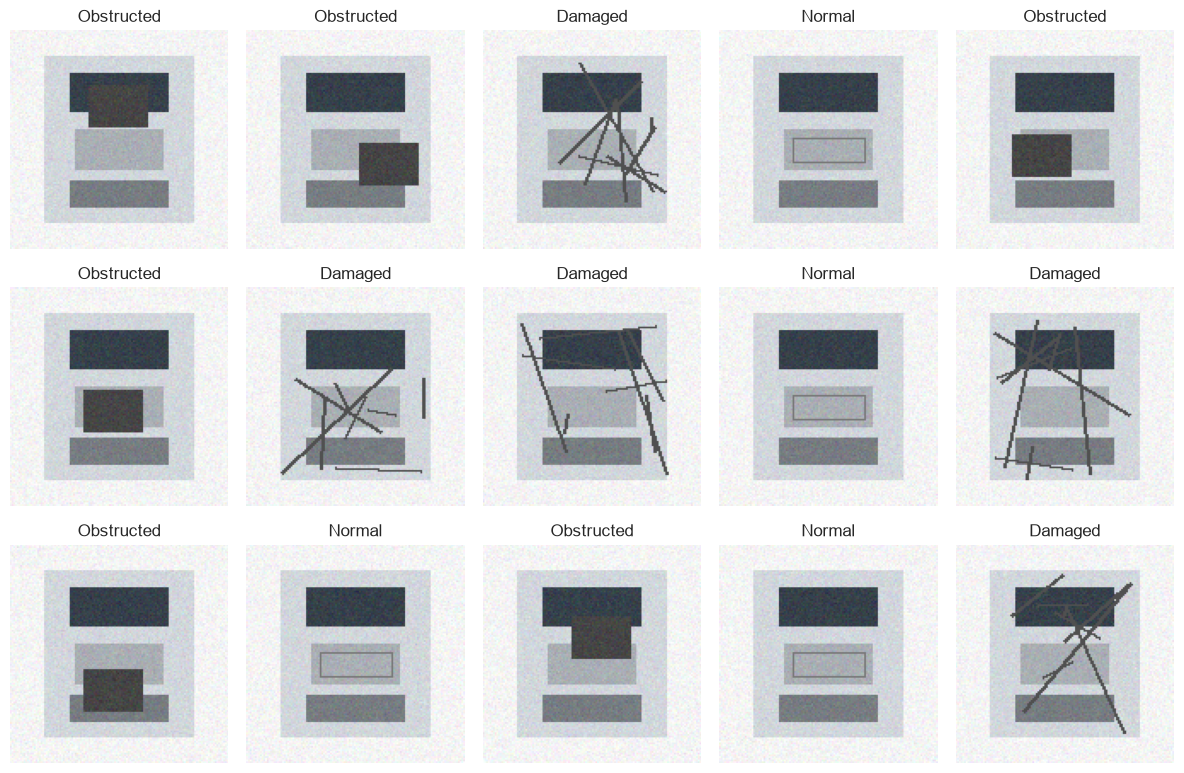

In [3]:
fig,axes=plt.subplots(3,5,figsize=(12,8))

for ax,(idx,row) in zip(axes.ravel(),metadata.sample(15,random_state=42).iterrows()):
    img=Image.open(DATA_DIR/row["Image"])
    ax.imshow(img)
    ax.set_title(row["Label"])
    ax.axis("off")

plt.tight_layout()
save_plot("5-visualize-sample-images.png")
plt.show()

## 6. Train / Validation / Test Split

We use:

```text
70% Train
15% Validation
15% Test
```

The test set is kept separate for final evaluation.

Stratification preserves class proportions.

In [4]:
train_meta,temp_meta=train_test_split(
    metadata,
    test_size=.30,
    stratify=metadata["Label"],
    random_state=42
)

val_meta,test_meta=train_test_split(
    temp_meta,
    test_size=.50,
    stratify=temp_meta["Label"],
    random_state=42
)

print("Train:",len(train_meta))
print("Validation:",len(val_meta))
print("Test:",len(test_meta))

Train: 210
Validation: 45
Test: 45


## 7. Image Preprocessing

Neural networks require a consistent input shape.

We resize every image to:

```text
128 × 128 × 3
```

and normalize pixel values from:

```text
0–255 → 0–1
```

In [5]:
IMG_SIZE=(128,128)
BATCH_SIZE=32

def load_images(meta):
    X=[]
    y=[]
    class_names=sorted(metadata["Label"].unique())
    class_to_id={c:i for i,c in enumerate(class_names)}

    for _,row in meta.iterrows():
        img=Image.open(DATA_DIR/row["Image"]).convert("RGB")
        img=img.resize(IMG_SIZE)
        X.append(np.asarray(img,dtype=np.float32)/255.0)
        y.append(class_to_id[row["Label"]])

    return np.array(X),np.array(y),class_names

X_train,y_train,class_names=load_images(train_meta)
X_val,y_val,_=load_images(val_meta)
X_test,y_test,_=load_images(test_meta)

print(X_train.shape,X_val.shape,X_test.shape)
print("Classes:",class_names)

(210, 128, 128, 3) (45, 128, 128, 3) (45, 128, 128, 3)
Classes: ['Damaged', 'Normal', 'Obstructed']


## 8. Baseline — Simple CNN

A small convolutional network is trained from scratch as the baseline. It establishes the accuracy a simple architecture reaches, so later improvements have an honest reference point.


In [6]:
cnn=models.Sequential([
    layers.Input(shape=(128,128,3)),

    layers.Conv2D(32,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(.30),
    layers.Dense(len(class_names),activation="softmax")
])

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Model Training

### Callbacks

**EarlyStopping**

Stops training when validation performance stops improving.

**ReduceLROnPlateau**

Reduces learning rate when validation loss plateaus.

In [7]:
callbacks=[
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=.5,
        patience=2
    )
]

history=cnn.fit(
    X_train,y_train,
    validation_data=(X_val,y_val),
    epochs=30,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30


1/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.4062 - loss: 1.0918

2/7 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.2812 - loss: 1.3863

3/7 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.2604 - loss: 1.7916

4/7 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.2812 - loss: 1.6871

...

4/7 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 1.0000 - loss: 0.0022

5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 1.0000 - loss: 0.0019

6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 1.0000 - loss: 0.0018

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 1.0000 - loss: 0.0017

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 0.0073 - learning_rate: 1.2500e-04


## 10. Training Curves

Training versus validation accuracy and loss are plotted per epoch. Diverging curves reveal overfitting early — before the model is evaluated on the test set.


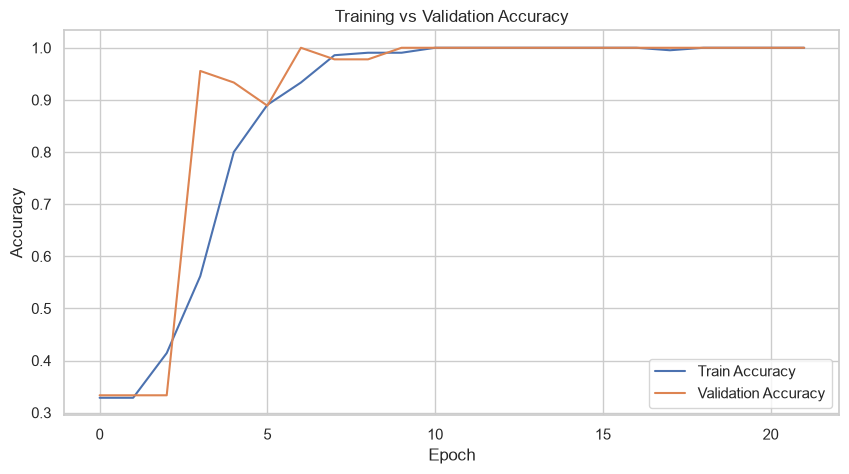

Saved: output/10-training-curves.png


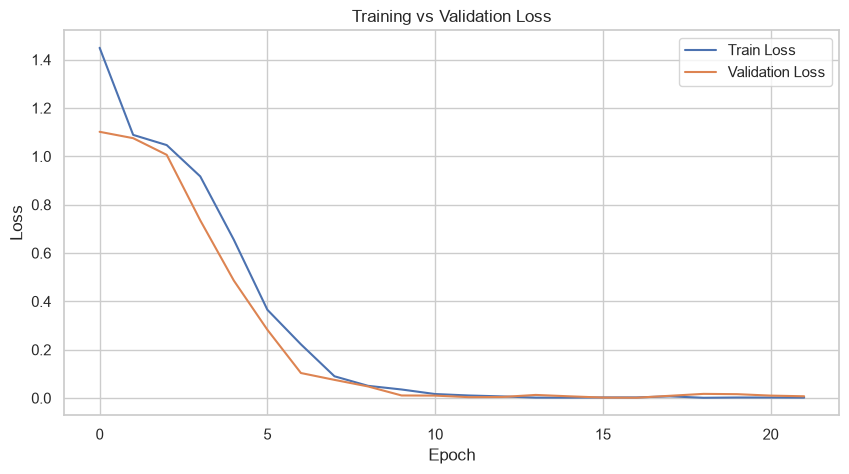

In [8]:
history_df=pd.DataFrame(history.history)

fig,ax=plt.subplots(figsize=(10,5))
ax.plot(history_df["accuracy"],label="Train Accuracy")
ax.plot(history_df["val_accuracy"],label="Validation Accuracy")
ax.set_title("Training vs Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
plt.show()

fig,ax=plt.subplots(figsize=(10,5))
ax.plot(history_df["loss"],label="Train Loss")
ax.plot(history_df["val_loss"],label="Validation Loss")
ax.set_title("Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
save_plot("10-training-curves.png")
plt.show()

## 11. Test Evaluation

The test set represents unseen images.

We evaluate using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

For operational applications, **recall for the damaged class** can be especially important because missing a damaged ATM may delay maintenance.

In [9]:
test_loss,test_acc=cnn.evaluate(X_test,y_test,verbose=0)
print("Test accuracy:",round(test_acc,4))
print("Test loss:",round(test_loss,4))

test_prob=cnn.predict(X_test,verbose=0)
test_pred=test_prob.argmax(axis=1)

print(classification_report(
    y_test,
    test_pred,
    target_names=class_names
))

Test accuracy: 1.0
Test loss: 0.002


              precision    recall  f1-score   support

     Damaged       1.00      1.00      1.00        15
      Normal       1.00      1.00      1.00        15
  Obstructed       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



Saved: output/11-test-evaluation.png


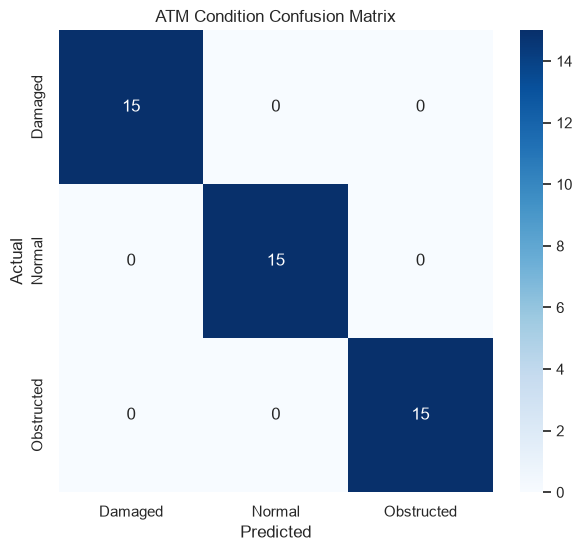

In [10]:
cm=confusion_matrix(y_test,test_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,annot=True,fmt="d",cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ATM Condition Confusion Matrix")
save_plot("11-test-evaluation.png")
plt.show()

## 12. What Makes a Good Computer Vision Model?

A good model should not be judged only by accuracy.

For maintenance use:

### Recall

```text
Of all actually damaged ATMs,
how many did we detect?
```

### Precision

```text
Of all ATMs predicted as damaged,
how many were actually damaged?
```

### F1

Balances precision and recall.

The appropriate metric depends on the business cost of false positives versus false negatives.

## 13. Predict a New Image

A helper function loads an arbitrary image, resizes it to the model's input size and returns the predicted class with its confidence. This single-image scoring is the unit of deployment for condition monitoring.


In [11]:
def predict_image(path,model=cnn):
    img=Image.open(path).convert("RGB").resize(IMG_SIZE)
    arr=np.asarray(img,dtype=np.float32)/255.0
    prob=model.predict(arr[None,...],verbose=0)[0]
    idx=int(prob.argmax())

    return {
        "Predicted_Class":class_names[idx],
        "Confidence":float(prob[idx]),
        "Probabilities":dict(zip(class_names,prob))
    }

example_path=DATA_DIR/metadata.iloc[0]["Image"]
print(predict_image(example_path))

{'Predicted_Class': 'Normal', 'Confidence': 0.9996258020401001, 'Probabilities': {'Damaged': np.float32(3.6965254e-08), 'Normal': np.float32(0.9996258), 'Obstructed': np.float32(0.00037414857)}}


## 14. Batch Prediction

The model scores every held-out test image and stores the results in a table. Batch scoring like this is how an ATM-monitoring pipeline would run in production, for example nightly per terminal.


In [12]:
results=[]

for _,row in test_meta.iterrows():
    result=predict_image(DATA_DIR/row["Image"])
    results.append({
        "Image":row["Image"],
        "Actual":row["Label"],
        "Predicted":result["Predicted_Class"],
        "Confidence":result["Confidence"]
    })

prediction_df=pd.DataFrame(results)
display(prediction_df.head(20))

,Image,Actual,Predicted,Confidence
0,normal_011.png,Normal,Normal,0.999686
1,obstructed_031.png,Obstructed,Obstructed,0.999500
2,damaged_094.png,Damaged,Damaged,1.000000
3,damaged_001.png,Damaged,Damaged,0.999997
4,normal_094.png,Normal,Normal,0.999677
5,normal_072.png,Normal,Normal,0.999664
6,obstructed_095.png,Obstructed,Obstructed,0.994704
7,normal_046.png,Normal,Normal,0.999680
8,normal_077.png,Normal,Normal,0.999646
9,normal_000.png,Normal,Normal,0.999626


## 15. Error Analysis

A strong Computer Vision project should inspect errors, not only metrics.

Questions:

- Which class is frequently confused?
- Are images blurry?
- Is lighting different?
- Is the damage too subtle?
- Does the dataset contain bias?
- Are there duplicate images?

Error analysis often reveals more actionable information than a single accuracy number.

In [13]:
errors=prediction_df[prediction_df["Actual"]!=prediction_df["Predicted"]]
print("Errors:",len(errors))
display(errors.head(20))

Errors: 0


,Image,Actual,Predicted,Confidence


## 16. Data Augmentation

Real ATM images can vary because of:

- camera angle,
- brightness,
- lighting,
- distance,
- rotation,
- partial obstruction.

Data augmentation can simulate some of these variations.

Typical transformations:

```text
Random Flip
Random Rotation
Random Zoom
Random Contrast
Random Translation
```

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.14816529..1.0035763].


Saved: output/16-data-augmentation.png


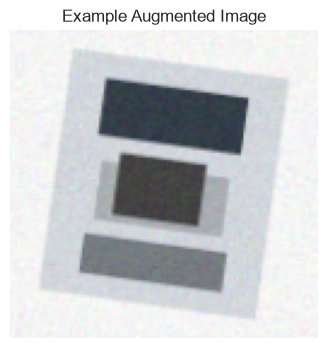

In [14]:
augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(.05),
    layers.RandomZoom(.10),
    layers.RandomContrast(.10)
])

sample=augmentation(X_train[:1],training=True)

plt.figure(figsize=(4,4))
plt.imshow(sample[0])
plt.axis("off")
plt.title("Example Augmented Image")
save_plot("16-data-augmentation.png")
plt.show()

## 17. CNN with Data Augmentation

For real-world images, augmentation should be part of training rather than applied to the test set.

The test set should represent realistic unseen data.

In [15]:
cnn_aug=models.Sequential([
    layers.Input(shape=(128,128,3)),
    augmentation,

    layers.Conv2D(32,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(.30),
    layers.Dense(len(class_names),activation="softmax")
])

cnn_aug.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_aug=cnn_aug.fit(
    X_train,y_train,
    validation_data=(X_val,y_val),
    epochs=20,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20


1/7 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3438 - loss: 1.0977

2/7 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.2969 - loss: 1.1017

3/7 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.2708 - loss: 1.1120

4/7 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.2891 - loss: 1.1112

...

4/7 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.8828 - loss: 0.4702

5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.8875 - loss: 0.4606

6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.8698 - loss: 0.4706

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.8619 - loss: 0.4821

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - accuracy: 0.8619 - loss: 0.4821 - val_accuracy: 0.5111 - val_loss: 0.6971 - learning_rate: 5.0000e-04


## 18. Transfer Learning

For a larger real-world project, training a CNN from scratch may not be the best first choice.

Transfer learning starts with a model pretrained on a large image dataset.

Examples:

- MobileNet
- EfficientNet
- ResNet
- ConvNeXt

Concept:

```text
Pretrained CNN
      ↓
Reuse visual features
      ↓
Fine-tune on banking images
      ↓
Bank-specific classifier
```

In [16]:
# Optional example. Requires internet/pretrained weights in many environments.
# from tensorflow.keras.applications import MobileNetV2
#
# base=MobileNetV2(
#     input_shape=(128,128,3),
#     include_top=False,
#     weights="imagenet"
# )
# base.trainable=False
#
# transfer=models.Sequential([
#     base,
#     layers.GlobalAveragePooling2D(),
#     layers.Dropout(.3),
#     layers.Dense(len(class_names),activation="softmax")
# ])
#
# transfer.compile(
#     optimizer="adam",
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"]
# )
#
# transfer.summary()

## 19. Explainability

Computer Vision models can make predictions that are difficult to interpret.

Useful methods include:

- Grad-CAM
- Integrated Gradients
- occlusion analysis

For example:

```text
Prediction = Damaged
        ↓
Grad-CAM
        ↓
Highlight image region
        ↓
Human verifies whether
the model focused on damage
```

Explainability is especially valuable for operational and regulated environments.

## 20. Production Architecture

```text
ATM Camera
    ↓
Image Ingestion
    ↓
Secure Storage
    ↓
Image Quality Check
    ↓
Computer Vision Model
    ↓
Condition Prediction
    ↓
Business Rules
    ↓
Maintenance Ticket
    ↓
Engineer Inspection
    ↓
Feedback
    ↓
Model Monitoring / Retraining
```

Example:

```text
Damaged + High Confidence
        ↓
Maintenance Alert

Low Confidence
        ↓
Human Review
```

## 21. Monitoring

Production Computer Vision requires monitoring beyond model accuracy.

### Data Monitoring
- image resolution
- brightness
- blur
- camera changes
- image distribution

### Model Monitoring
- accuracy
- recall
- precision
- confidence distribution
- class distribution

### Operational Monitoring
- maintenance response time
- false alarms
- missed damage
- inspection outcomes

## 22. Common Computer Vision Mistakes

1. Randomly splitting near-duplicate images.
2. Data leakage between train and test.
3. Training with inconsistent image sizes.
4. Ignoring class imbalance.
5. Evaluating only accuracy.
6. Overfitting to one camera/location.
7. Using unrealistic augmentation.
8. Ignoring image quality.
9. Deploying without confidence thresholds.
10. Not performing error analysis.

## 23. Real Banking Computer Vision Extensions

After ATM classification, the same workflow can be extended to:

### Document Classification
```text
KTP / Passport / Supporting Document
          ↓
Document Classifier
```

### Cheque Image Processing
```text
Cheque Image
    ↓
OCR + CV
    ↓
Amount / Date / Signature
```

### ATM Monitoring
```text
Camera
  ↓
Object Detection
  ↓
Queue / Obstruction / Damage
```

### ID Verification
```text
Document
   +
Selfie
   ↓
Face / Document Verification
```

For these applications, privacy, security, consent, and regulatory controls are critical.

# Final Executive Summary

## Business Problem

Banks can use images to automate inspection and document-related workflows.

## Project

**ATM Condition Classification**

```text
ATM Image
    ↓
Preprocessing
    ↓
CNN
    ↓
Normal / Damaged / Obstructed
    ↓
Business Rule
    ↓
Maintenance Action
```

## Techniques Covered

- Image preprocessing
- CNN
- Train / validation / test split
- Data augmentation
- Classification metrics
- Confusion matrix
- Error analysis
- Transfer learning concept
- Explainability concept
- Production architecture
- Monitoring

### Key takeaway

> **Computer Vision is not only about recognizing images. In banking, the important part is connecting visual predictions to a controlled operational workflow.**

## 24. Save Outputs

All key result tables and figures are saved into the local `output/` folder, so results survive after the kernel is restarted and can be shared without re-running the notebook.


In [17]:
prediction_df.to_csv(OUTPUT_DIR / "atm_image_predictions.csv", index=False)
print("Saved:", OUTPUT_DIR / "atm_image_predictions.csv")
history_df.to_csv(OUTPUT_DIR / "cnn_training_history.csv", index=False)
print("Saved:", OUTPUT_DIR / "cnn_training_history.csv")


# List everything that was written to output/
for _p in sorted(OUTPUT_DIR.iterdir()):
    print(" ", _p)


Saved: output/atm_image_predictions.csv
Saved: output/cnn_training_history.csv
  output/10-training-curves.png
  output/11-test-evaluation.png
  output/16-data-augmentation.png
  output/5-visualize-sample-images.png
  output/atm_image_predictions.csv
  output/cnn_training_history.csv
